# Exercises week 35

**FYS-STK3155/4155 — Applied Data Analysis and Machine Learning**

**August 24–30, 2026. Deadline: Friday August 28 at midnight.**

Reading for this set: the book, Chapter 3 (in particular Sections 3.1–3.7 from
week 34 and Sections 3.7–3.10 and 3.13 from this week), and the week 35 slides
(`week35slides.pdf`, `week35tuesday.pdf`). The Tuesday session and its notebook
(`week35tuesday.ipynb`) walk through most of the code you need here. For
exercise 1 the book by Faisal, Ong and Deisenroth, *Mathematics for Machine
Learning*, chapter 5 (sections 5.3–5.5) at https://mml-book.github.io/ is very
useful.

## Exercise 1: Analytical exercises

In this exercise we derive the expressions for various derivatives of products of
vectors and matrices. Such derivatives are central to the optimization of various
cost functions. Although we will often use automatic differentiation in actual
calculations, having the analytical expressions is extremely helpful in case we
have simpler derivatives, as well as when we analyze various properties (like
second derivatives) of the chosen cost functions. Vectors are always written as
boldfaced lower-case letters and matrices as upper-case boldfaced letters.
Note that throughout we use the numerator (Jacobian) layout, in which the derivative of a
*scalar* with respect to a vector is a **row** vector — consistent with the example
$\partial(\boldsymbol{A}\boldsymbol{x})/\partial\boldsymbol{x}=\boldsymbol{A}$ in the hint below and with Faisal et al.; if you prefer the
column-gradient convention you will obtain the equivalent transposed results, e.g.
$(\boldsymbol{A}+\boldsymbol{A}^T)\boldsymbol{a}$ instead of $\boldsymbol{a}^T(\boldsymbol{A}+\boldsymbol{A}^T)$.

Show that

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{x})}{\partial \boldsymbol{x}} = \boldsymbol{a}^T,
$$

and

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{A}\boldsymbol{a})}{\partial \boldsymbol{a}} = \boldsymbol{a}^T\left(\boldsymbol{A}+\boldsymbol{A}^T\right),
$$

and

$$
\frac{\partial \left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)^T\left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)}{\partial \boldsymbol{s}} = -2\left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)^T\boldsymbol{A},
$$

and finally find the second derivative of this function with respect to the vector
$\boldsymbol{s}$.

If we replace the vector $\boldsymbol{s}$ with the unknown parameters
$\boldsymbol{\theta}$ used to define the ordinary least squares method, we end up
with the equations that determine these parameters. The matrix $\boldsymbol{A}$ is
then the design matrix $\boldsymbol{X}$, and $\boldsymbol{x}$ has to be replaced
with the outputs $\boldsymbol{y}$. The second derivative of the mean squared error
is then proportional to the Hessian matrix
$\boldsymbol{H}=\boldsymbol{X}^T\boldsymbol{X}$.

**Hint:** it is always useful to write out with summation indices the various
quantities; take a look at the examples in the week 35 slides. As an example,
consider the function

$$
f(\boldsymbol{x}) = \boldsymbol{A}\boldsymbol{x},
$$

which reads for a specific component $f_i$ (defining $\boldsymbol{A}$ to be an
$n\times n$ matrix and $\boldsymbol{x}$ a vector of length $n$)

$$
f_i = \sum_{j=0}^{n-1} a_{ij} x_j,
$$

which leads to

$$
\frac{\partial f_i}{\partial x_j} = a_{ij},
$$

and written out in terms of the vector $\boldsymbol{x}$ we have

$$
\frac{\partial f(\boldsymbol{x})}{\partial \boldsymbol{x}} = \boldsymbol{A}.
$$

## Exercise 2: Making your own data and exploring scikit-learn

We will generate our own dataset for a function $y(x)$ where $x\in[0,1]$ and
defined by random numbers computed with the uniform distribution. The function $y$
is a quadratic polynomial in $x$ with added stochastic noise according to the
normal distribution $\mathcal{N}(0,1)$. The following simple Python instructions
define our $x$ and $y$ values (with 100 data points).

In [1]:
import numpy as np

rng = np.random.default_rng(2026)
x = rng.random((100, 1))
y = 2.0 + 5.0 * x * x + 0.1 * rng.standard_normal((100, 1))

1. Write your own code (following the examples in the book, Chapter 3, and the
   week 34–35 slides) for computing the parametrization of the data set, fitting a
   second-order polynomial. That is, set up the design matrix
   $\boldsymbol{X}$ with columns $1, x, x^2$ and find the optimal parameters
   $\boldsymbol{\theta}$ from the normal equations (or, better, through the SVD —
   see the week 34 discussion of why we never invert
   $\boldsymbol{X}^T\boldsymbol{X}$).

2. Use thereafter **scikit-learn** (see the examples in the week 35 slides and the
   Tuesday notebook) and compare with your own code. Note that scikit-learn does
   not, by default, include the intercept in the design matrix. See the
   discussions on scaling your data in the week 35 slides (and Section 3.13 of the
   book). This type of problem appears in particular if we fit a polynomial with
   an intercept.

3. Using scikit-learn, compute also the mean squared error, a risk metric
   corresponding to the expected value of the squared (quadratic) error

$$
MSE(\boldsymbol{y},\tilde{\boldsymbol{y}}) = \frac{1}{n}\sum_{i=0}^{n-1}\left(y_i-\tilde{y}_i\right)^2,
$$

   and the $R^2$ score function. If $\tilde{y}_i$ is the predicted value of the
   $i$-th sample and $y_i$ is the corresponding true value, then the $R^2$ score is

$$
R^2(\boldsymbol{y},\tilde{\boldsymbol{y}}) = 1 - \frac{\sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2}{\sum_{i=0}^{n-1}(y_i-\bar{y})^2},
$$

   where the mean value of $\boldsymbol{y}$ is

$$
\bar{y} = \frac{1}{n}\sum_{i=0}^{n-1} y_i.
$$

   You can use the functionality included in scikit-learn, or your own functions
   from the Tuesday notebook. Discuss the meaning of these results. Try also to
   vary the coefficient in front of the added stochastic noise term and discuss
   the quality of the fits.

In [1]:
# Your code for exercise 2 here
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

n = 100
rng = np.random.default_rng(2026)
x = rng.random((n, 1))

for sigma in[0.001,0.01,0.1]:
    print("\n Noise level sigma =", sigma)
    y = 2.0 + 5.0 * x * x + sigma * rng.standard_normal((n, 1))

    X_comp = np.hstack([np.ones((n,1)),x,x**2])

    beta_hat_comp, residuals, rank, s = np.linalg.lstsq(X_comp, y, rcond=None)

    print("beta_hat (normal equations):")
    print(beta_hat_comp.ravel())

    #prediction for the computed data
    y_comp = X_comp @ beta_hat_comp

    #mean squared error for the computed data
    mse_comp = np.mean((y-y_comp)**2)

    y_mean = np.mean(y)
    ss_res = np.sum((y - y_comp)**2)
    ss_tot = np.sum((y - y_mean)**2)
    r2_comp = 1 - ss_res / ss_tot

    print("MSE (manual):", mse_comp)
    print("R^2 (manual):", r2_comp)

    poly = PolynomialFeatures(degree=2, include_bias=True)  
    X_skl = poly.fit_transform(x) 

    model = LinearRegression(fit_intercept=False)
    model.fit(X_skl, y)

    beta_skl = model.coef_.ravel()  
    print("beta_hat (scikit-learn):")
    print(beta_skl)

    y_skl = model.predict(X_skl)

    mse_skl = mean_squared_error(y,y_skl)
    r2_skl = r2_score(y,y_skl)

    print("MSE (scikit-learn):", mse_skl)
    print("R^2 (scikit-learn):", r2_skl)


 Noise level sigma = 0.001
beta_hat (normal equations):
[ 2.00029563e+00 -4.83290884e-04  5.00018567e+00]
MSE (manual): 1.3728156746261843e-06
R^2 (manual): 0.9999992892981521
beta_hat (scikit-learn):
[ 2.00029563e+00 -4.83290884e-04  5.00018567e+00]
MSE (scikit-learn): 1.3728156746261843e-06
R^2 (scikit-learn): 0.9999992892981521

 Noise level sigma = 0.01
beta_hat (normal equations):
[ 2.00296031 -0.0130261   5.01228011]
MSE (manual): 9.363784835510719e-05
R^2 (manual): 0.9999515415477851
beta_hat (scikit-learn):
[ 2.00296031 -0.0130261   5.01228011]
MSE (scikit-learn): 9.363784835510719e-05
R^2 (scikit-learn): 0.9999515415477851

 Noise level sigma = 0.1
beta_hat (normal equations):
[1.97909251 0.06767917 4.9486548 ]
MSE (manual): 0.010092378889340612
R^2 (manual): 0.9948229070759703
beta_hat (scikit-learn):
[1.97909251 0.06767917 4.9486548 ]
MSE (scikit-learn): 0.010092378889340612
R^2 (scikit-learn): 0.9948229070759703


## Exercise 3: Split data in test and training data

In this exercise we want you to compute the MSE for the training data and the test
data as a function of the complexity of a polynomial, that is the degree of a given
polynomial.

The aim is to reproduce Figure 2.11 of Hastie et al., *The Elements of Statistical
Learning*. Feel free to read the discussions leading to that figure.

Our data is defined by $x\in[-3,3]$ with a total of, for example, $n=100$ data
points. You should try to vary the number of data points $n$ in your analysis.

In [3]:
n = 100
x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + rng.normal(0, 0.1, x.shape)

where $y$ is the function we want to fit with a given polynomial.

1. Write a first code which sets up a design matrix $\boldsymbol{X}$ defined by a
   fifth-order polynomial and split your data set into training and test data
   (`sklearn.model_selection.train_test_split` is fine).

2. Write thereafter (using either scikit-learn or your matrix inversion/SVD code)
   an ordinary least squares fit and compute the mean squared error for the
   training data and the test data. These calculations should apply to a model
   given by a fifth-order polynomial. If you compare your own code with
   scikit-learn, note that the latter does not include the intercept by default —
   see the discussions on scaling in the week 35 slides.

3. Add now a model which allows you to make polynomials up to degree $15$. Perform
   a standard OLS fit of the training data and compute the MSE for the training
   and test data and plot both as functions of the polynomial degree. Compare what
   you see with Figure 2.11 of Hastie et al. Comment on your results. For which
   polynomial degree do you find the optimal (smallest) test MSE?

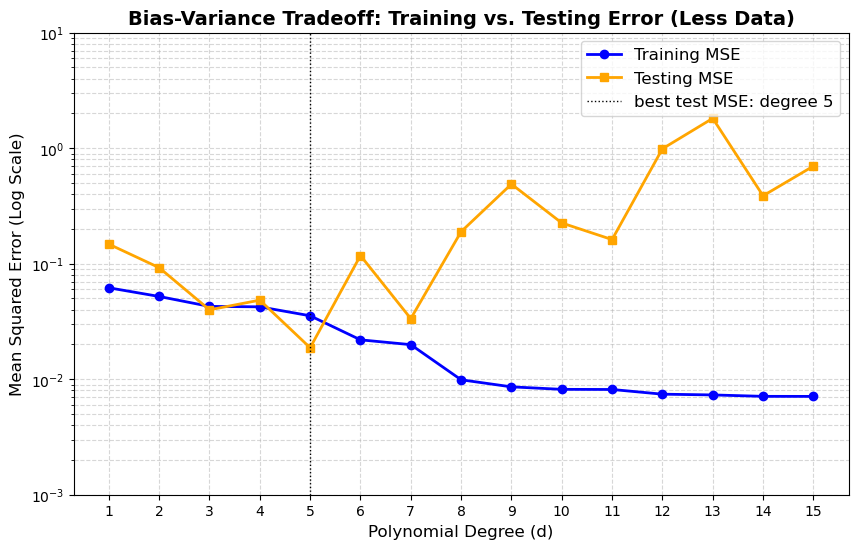

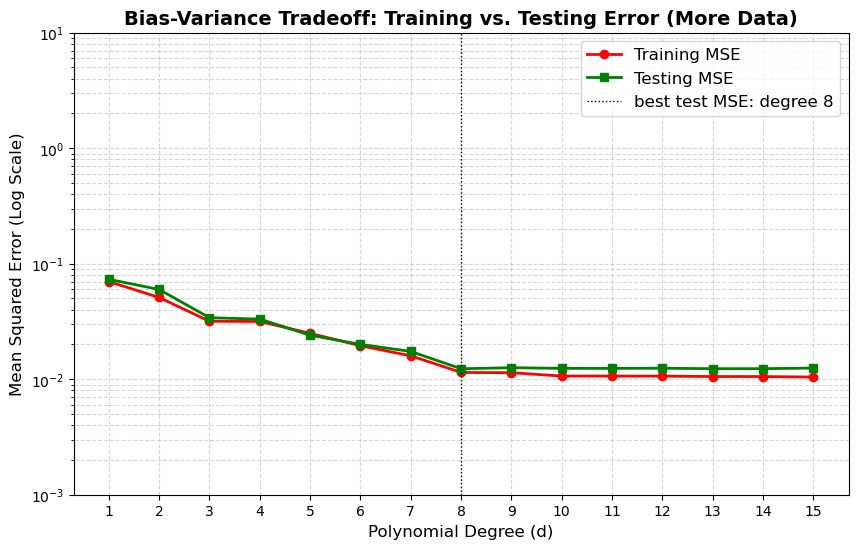

In [7]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as MSE
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
#The last point says "You should try varying the number of data points in your analysis" so I'm essentially doing this twice.
#n has less data points. This represents over fitting
n = 100
#m has more data points. This represents a better fit
m = 500

#Since we're doing two curves with two sets of data points, I duplicated the synthetic data.
#this breaks up our lines into n or m number of sections respectively.
#more specifically "between -3 and 3. break our curve up into n sections, and get our points"
#this is where the fact that we define the number of points differently really matters
i = np.linspace(-3, 3, n)
j = np.linspace(-3, 3, m)

#This is where we assign the division criteria to the assigned function
y = np.exp(-i**2) + 1.5*np.exp(-(i - 2)**2) + rng.normal(0, 0.1, n)
z = np.exp(-j**2) + 1.5*np.exp(-(j - 2)**2) + rng.normal(0, 0.1, m)

#this divides our data between training and testing data. 
#Because I used i divisions to assign our y function. I kept the same naming conventions here
#same thing for j and z
#i and j replace the x in our function. y and z replace y in our function. This would make a lot more sense if I kept the standards x/y criteria
#train_test_split (x_fun, y_fun, test_size, rand_num)
#test_size is to be converted into percent. so we're reserving 30% of the data for validation
#rand_num is a random seed to essentially randomize our plots. If we chose a different number, our plots may look slightly different.
i_train, i_test, y_train, y_test = train_test_split(i, y, test_size=0.3, random_state=2026)
j_train, j_test, z_train, z_test = train_test_split(j, z, test_size=0.3, random_state=2026)

# Initialize the list containers before the loop
#This is just standard programming practice. Initiallize variables before assign.
mse_train_y = []
mse_test_y = []

mse_train_z = []
mse_test_z = []

for d in range(1, 16):
    #np.vander introduces a vandermond matrix which is essentially a row of powers
    #Since we're creating a line that is a polinomial, we need the vandermond matrix to set the baseline of our polinomial equation
    Itr = np.vander(i_train, d + 1, increasing=True)
    Ite = np.vander(i_test, d + 1, increasing=True)
    #"Here's my polynomial matrix. here's my data. solve it"
    #Itr is the matrix
    #y_train is the training data
    thetaI = np.linalg.lstsq(Itr, y_train, rcond=None)[0] # SVD based

    Jtr = np.vander(j_train, d + 1, increasing=True)
    Jte = np.vander(j_test, d + 1, increasing=True)
    thetaJ = np.linalg.lstsq(Jtr, z_train, rcond=None)[0] # SVD based

    #calculate the mean_square_error of the data
    mse_train_y.append(MSE(y_train, Itr @ thetaI))
    mse_test_y.append(MSE(y_test, Ite @ thetaI))

    mse_train_z.append(MSE(z_train, Jtr @ thetaJ))
    mse_test_z.append(MSE(z_test, Jte @ thetaJ))

y_best_d = degrees[int(np.argmin(mse_test_y))]
z_best_d = degrees[int(np.argmin(mse_test_z))]

# Create the plot for smaller dataset
plt.figure(figsize=(10, 6))
degrees = range(1, 16)

# Plot both curves
plt.plot(degrees, mse_train_y, marker='o', label='Training MSE', color='blue', linewidth=2)
plt.plot(degrees, mse_test_y, marker='s', label='Testing MSE', color='orange', linewidth=2)
plt.axvline(y_best_d, color="black", ls=":", lw=1, label=f"best test MSE: degree {y_best_d}")

# Customizing the chart
plt.yscale('log') # Log scale helps visualize dramatic spikes in test error
plt.xlabel('Polynomial Degree (d)', fontsize=12)
plt.ylabel('Mean Squared Error (Log Scale)', fontsize=12)
plt.title('Bias-Variance Tradeoff: Training vs. Testing Error (Less Data)', fontsize=14, fontweight='bold')
plt.xticks(degrees)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=12)


# Display the plot
#this is just a line of code because the huge error on the orange line was hiding the legand
plt.ylim(1e-3, 1e1) 
plt.show()

# Create the plot for smaller dataset
plt.figure(figsize=(10, 6))
degrees = range(1, 16)

# Plot both curves
plt.plot(degrees, mse_train_z, marker='o', label='Training MSE', color='red', linewidth=2)
plt.plot(degrees, mse_test_z, marker='s', label='Testing MSE', color='green', linewidth=2)
plt.axvline(z_best_d, color="black", ls=":", lw=1, label=f"best test MSE: degree {z_best_d}")

# Customizing the chart
plt.yscale('log') # Log scale helps visualize dramatic spikes in test error
plt.xlabel('Polynomial Degree (d)', fontsize=12)
plt.ylabel('Mean Squared Error (Log Scale)', fontsize=12)
plt.title('Bias-Variance Tradeoff: Training vs. Testing Error (More Data)', fontsize=14, fontweight='bold')
plt.xticks(degrees)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=12)


# Display the plot
plt.ylim(1e-3, 1e1) 
plt.show()# Your code for exercise 3 here


## Exercise 4 (optional): a first taste of Ridge

This voluntary exercise connects directly to Monday's lecture and to Case 4 of the
Tuesday notebook; it is also a useful warm-up for Project 1.

Keep the data set and the degree-15 design matrix from exercise 3, standardise the
feature columns (training statistics only!), and replace OLS by Ridge regression,

$$
\hat{\boldsymbol{\theta}}_{\mathrm{Ridge}} = \left(\boldsymbol{X}^T\boldsymbol{X}+\lambda\boldsymbol{I}\right)^{-1}\boldsymbol{X}^T\boldsymbol{y}.
$$

1. Plot the training and test MSE as functions of $\lambda$ on a logarithmic grid,
   say $\lambda\in[10^{-8},10^{4}]$. Do you find the U-shape discussed in the
   lecture?

2. Compare your best test MSE with the best value found in exercise 3 by varying
   the polynomial degree. Two dials, one phenomenon — which gives the finer
   control?

3. Check explicitly that your training MSE is monotonically increasing in
   $\lambda$, and explain in one sentence why it must be.

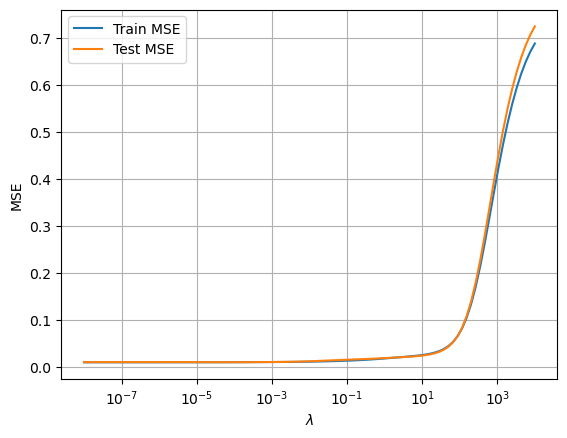

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as MSE
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
#The last point says "You should try varying the number of data points in your analysis" so I'm essentially doing this twice.
#n has less data points. This represents over fitting
n = 500

#Since we're doing two curves with two sets of data points, I duplicated the synthetic data.
#this breaks up our lines into n or m number of sections respectively.
#more specifically "between -3 and 3. break our curve up into n sections, and get our points"
#this is where the fact that we define the number of points differently really matters
x = np.linspace(-3, 3, n)

#This is where we assign the division crXteria to the assigned function
y = np.exp(-x**2) + 1.5*np.exp(-(x - 2)**2) + rng.normal(0, 0.1, n)

#this divides our data between training and testing data. 
#Because I used i divisions to assign our y function. I kept the same naming conventions here
#same thing for j and z
#i and j replace the x in our function. y and z replace y in our function. This would make a lot more sense if I kept the standards x/y crXteria
#train_test_split (x_fun, y_fun, test_size, rand_num)
#test_size is to be converted into percent. so we're reserving 30% of the data for validation
#rand_num is a random seed to essentially randomize our plots. If we chose a different number, our plots may look slightly different.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=2026)

# Initialize the list containers before the loop
#This is just standard programming practice. Initiallize variables before assign.
mse_train_y = []
mse_test_y = []

d = 15  # fixed polynomial degree

# Build design matrices ONCE (outside the lambda loop)
Xtr = np.vander(x_train, d + 1, increasing=True)
Xte = np.vander(x_test,  d + 1, increasing=True)

# Standardise using training stats
mu    = Xtr[:, 1:].mean(axis=0)
sigma = Xtr[:, 1:].std(axis=0, ddof=0)

Xtr[:, 1:] = (Xtr[:, 1:] - mu) / sigma
Xte[:, 1:] = (Xte[:, 1:] - mu) / sigma

p = Xtr.shape[1]
I = np.eye(p)

lambdas = np.logspace(-8, 4, 100)
mse_train_y = []
mse_test_y  = []

for lam in lambdas:
    #"Here's my polynomial matrix. here's my data. solve it"
    #Xtr is the matrix
    #y_train is the training data
    # Ridge solution for this λ (degree still 15)
    #loop on exercise 3 was for the OLS function
    theta_ridge = np.linalg.solve(
        Xtr.T @ Xtr + lam * I,
        Xtr.T @ y_train
    )

    # Predictions
    y_train_pred = Xtr @ theta_ridge
    y_test_pred  = Xte @ theta_ridge

    # MSE
    mse_train_y.append(MSE(y_train, y_train_pred))
    mse_test_y.append(MSE(y_test,  y_test_pred))

train_mse = np.array(mse_train_y)
test_mse  = np.array(mse_test_y)

plt.figure()
plt.semilogx(lambdas, train_mse, label="Train MSE")
plt.semilogx(lambdas, test_mse,  label="Test MSE")
plt.xlabel(r"$\lambda$")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()